In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# Part A - Cleaning & Sentiment Overview

#import dataset
df = pd.read_csv("Climate_Tweets_Sample.csv")

#change date format
df["date"] = pd.to_datetime(df['date'])

#drop duplicate values
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after removal:", df.duplicated().sum())

#deal with empty values - for like and retweet count
df['like_count'] = df['like_count'].fillna(0)
df['retweet_count'] = df['retweet_count'].fillna(0)

#are filled with 0 since empty value likely indicates no interaction/engagement with tweet 
#instead of it being corrupted or bad data

#adjust column names to be easier to read when in charts/graphs
df.columns = df.columns.str.replace('_',' ').str.title()

#adjust row data to be easier to read
df['Sentiment'] = df['Sentiment'].str.capitalize()
df['Keyword'] = df['Keyword'].str.capitalize()

Duplicates: 0
Duplicates after removal: 0


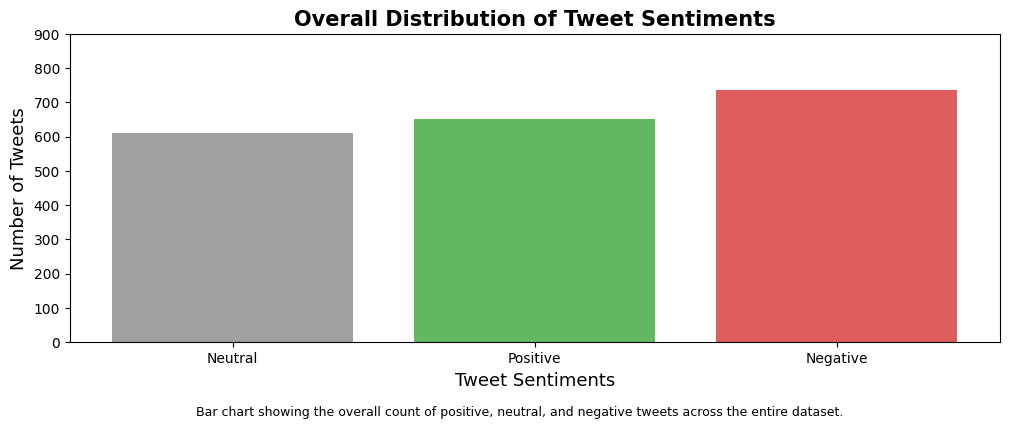

In [2]:
import matplotlib.pyplot as plt

#grey, green and red to clearly show neutral, positive and negative
#these colours are used since they are intuitive
colours = ['#7f7f7f', '#2ca02c', '#d62728']

sentiment_counts = df['Sentiment'].value_counts().sort_values()
plt.figure(figsize=(12,4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=colours[:len(sentiment_counts)], alpha=0.75)
plt.xlabel("Tweet Sentiments", fontsize = 13)
plt.ylabel("Number of Tweets", fontsize = 13)
plt.ylim(0,900)
plt.title("Overall Distribution of Tweet Sentiments", fontsize = 15, fontweight='bold')
plt.figtext(0.5, -0.075,
            "Bar chart showing the overall count of positive, neutral, and negative tweets across the entire dataset.",
            wrap=True, ha='center', fontsize=9)
plt.show()

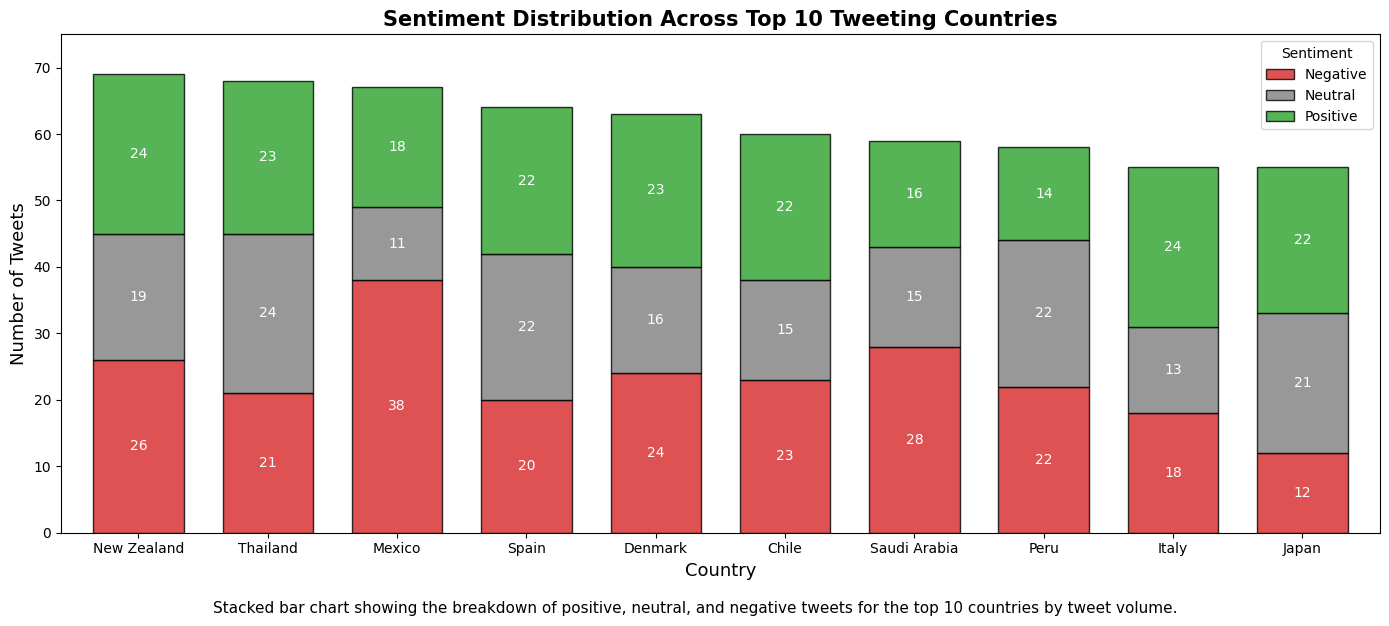

In [3]:
top10_countries = df['Country'].value_counts().head(10).index
df_top10 = df[df['Country'].isin(top10_countries)]

sentiment_by_country = df_top10.groupby(['Country', 'Sentiment']).size().unstack(fill_value=0)

#reorder columns for consistent colouring
sentiment_by_country = sentiment_by_country[['Negative', 'Neutral', 'Positive']]

#sort by total tweets per country to allow for easier reading of the chart
sentiment_by_country['Total'] = sentiment_by_country.sum(axis=1)
sentiment_by_country = sentiment_by_country.sort_values(by='Total', ascending=False)
sentiment_by_country = sentiment_by_country.drop(columns='Total')

#same sentiment colours as they are intuitive
sentiment_colours = ['#d62728', '#7f7f7f', '#2ca02c']

ax = sentiment_by_country.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    color=sentiment_colours,
    alpha=0.8,
    edgecolor='black',
    width=0.7
)

#show labels for the stacked segments so exact counts per sentiment are visible
for i, country in enumerate(sentiment_by_country.index):
    bottom = 0
    for j, sentiment in enumerate(sentiment_by_country.columns):
        value = sentiment_by_country.loc[country, sentiment]
        plt.text(i, bottom + value/2, str(value), ha='center', va='center', fontsize=10, color='white')
        bottom += value

plt.xlabel("Country", fontsize=13)
plt.ylabel("Number of Tweets", fontsize=13)
plt.title("Sentiment Distribution Across Top 10 Tweeting Countries",
          fontsize=15, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim(0,75)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.figtext(0.5, -0.03,
            "Stacked bar chart showing the breakdown of positive, neutral, and negative tweets for the top 10 countries by tweet volume.",
            wrap=True, ha='center', fontsize=11)
plt.show()

In [4]:
#Part B – Text Preprocess & Word Cloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#lowercasing
df['Cleaned Text'] = df['Text'].str.lower()

#punctuation removal
df['Cleaned Text'] = df['Cleaned Text'].apply(
    lambda x: re.sub(r'[^a-z0-9\s]', '', x)
)

#stopword removal
df['Cleaned Text'] = df['Cleaned Text'].apply(
    lambda x: ' '.join(
        word for word in x.split() if word not in stop_words
    )
)

#lemmatization - convert words to base dictionary form
df['Cleaned Text'] = df['Cleaned Text'].apply(
    lambda x: ' '.join(
        lemmatizer.lemmatize(word) for word in x.split()
    )
)

#saved cleaned dataset
df.to_csv("Climate_Tweets_Sample_Cleaned.csv", index=False) 

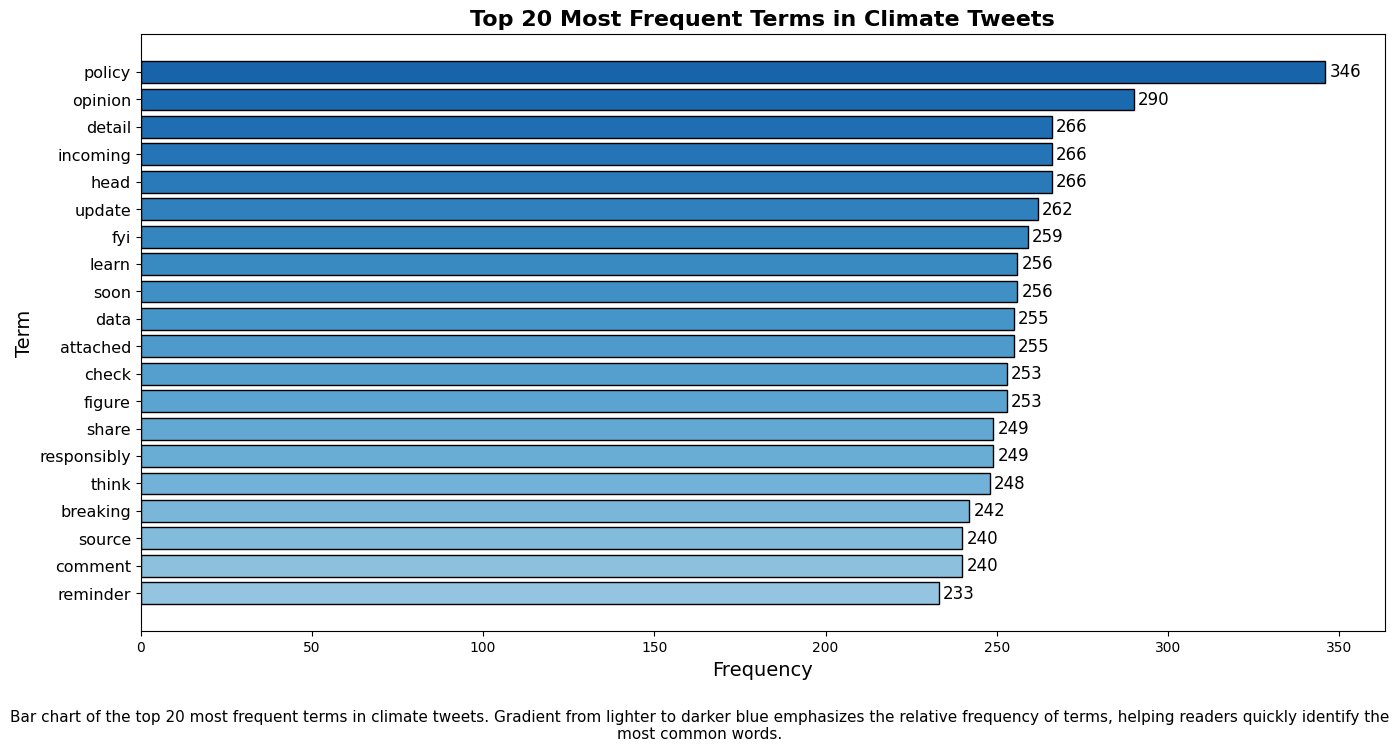

In [5]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.cm as cm

#20 most frequent terms chart

all_words = ' '.join(df['Cleaned Text'].dropna()).split()

word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

words  = [w for w, _ in top_20]
counts = [c for _, c in top_20]

#gradient colours used to visually emphasize the relative frequency of the top 20 terms
#darker blue bars indicate higher counts, allowing readers to quickly identify them
colours = cm.Blues(np.linspace(0.4, 0.8, len(words)))

plt.figure(figsize=(14, 7))
bars = plt.barh(words[::-1], counts[::-1], color=colours, edgecolor='black')

for bar, count in zip(bars, counts[::-1]):
    plt.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2,
             str(count), va='center', fontsize=12)

plt.title('Top 20 Most Frequent Terms in Climate Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Term', fontsize=14)
plt.yticks(fontsize=11.5) # increase y-axis label font size
plt.tight_layout()
plt.figtext(0.5, -0.06,
            "Bar chart of the top 20 most frequent terms in climate tweets. Gradient from lighter to darker blue emphasizes the relative frequency of terms, helping readers quickly identify the most common words.",
            wrap=True, ha='center', fontsize=11)
plt.show()

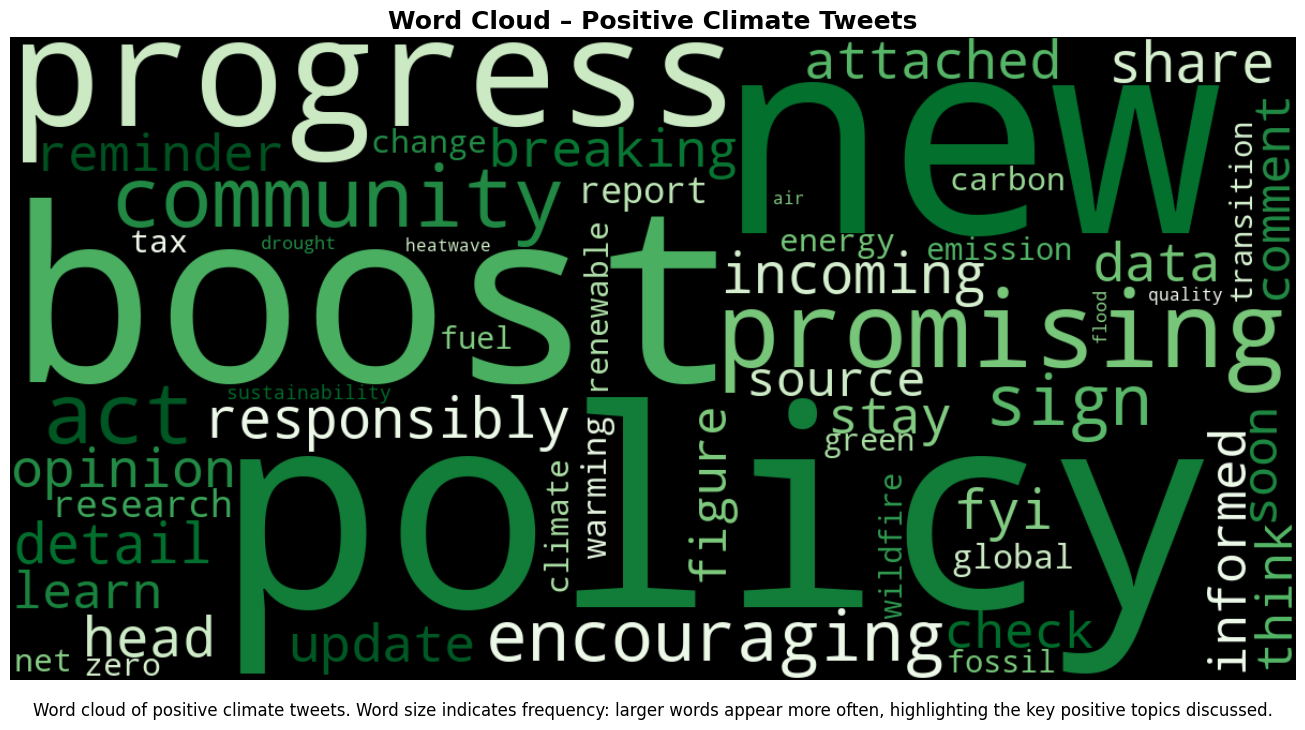

In [6]:
#positive tweets
positive_text = ' '.join(
    df[df['Sentiment'] == 'Positive']['Cleaned Text'].dropna()
)

if positive_text.strip():
    wc_positive = WordCloud(
        width=1200,
        height=600,
        background_color='black', #use black background to make words stand out more
        colormap='Greens', #use green as it is associated with positive    
        max_words=100,
        collocations=False,
        contour_width=1,
        contour_color='white'
    ).generate(positive_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc_positive, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud – Positive Climate Tweets', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.figtext(0.5, -0.03, 
            "Word cloud of positive climate tweets. Word size indicates frequency: larger words appear more often, highlighting the key positive topics discussed.",
            wrap=True, ha='center', fontsize=12)
    plt.show()
else:
    print("No positive tweets found.")

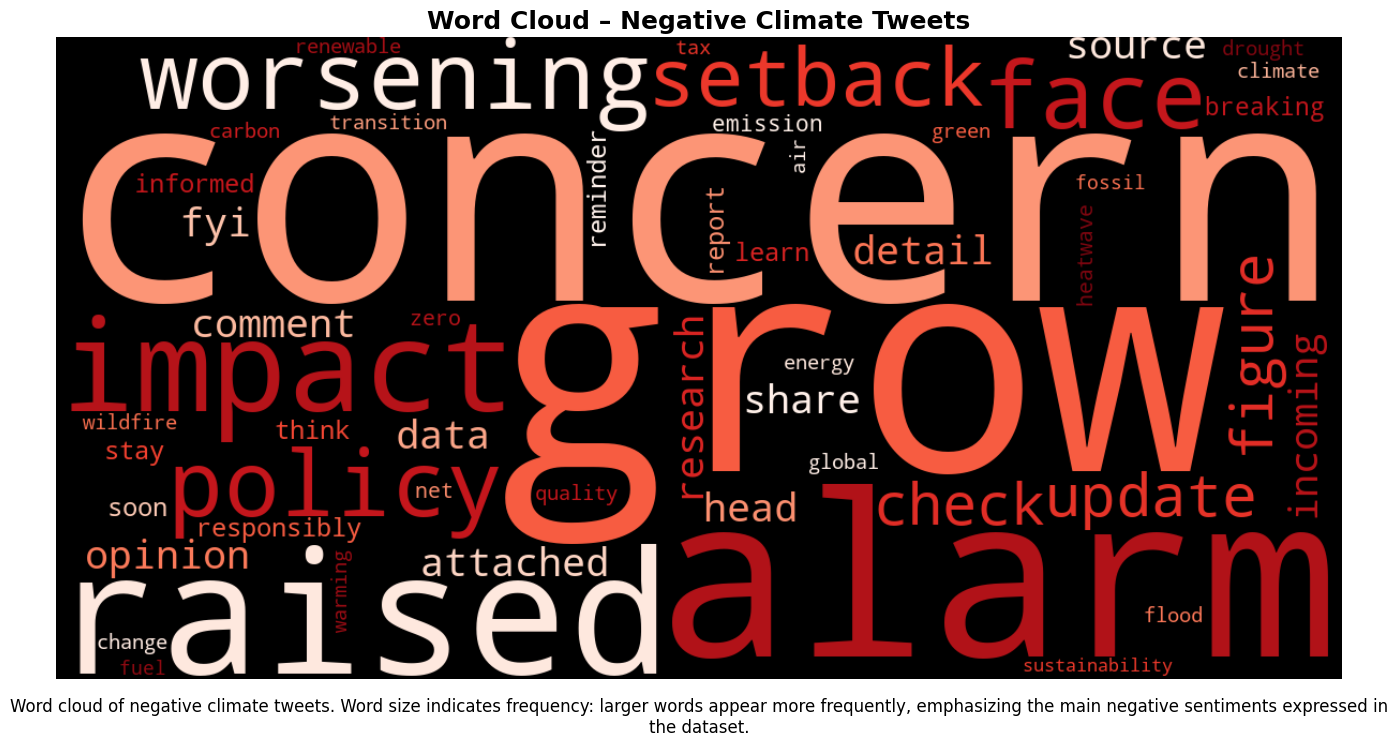

In [7]:
#negative tweets
negative_text = ' '.join(
    df[df['Sentiment'] == 'Negative']['Cleaned Text'].dropna()
)

if negative_text.strip():
    wc_negative = WordCloud(
        width=1200,
        height=600,
        background_color='black', #use black background to make words stand out more
        colormap='Reds', #use red as it is associated with negative          
        max_words=100,
        collocations=False,
        contour_width=1,
        contour_color='white'
    ).generate(negative_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc_negative, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud – Negative Climate Tweets', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.figtext(0.5, -0.05, 
            "Word cloud of negative climate tweets. Word size indicates frequency: larger words appear more frequently, emphasizing the main negative sentiments expressed in the dataset.",
            wrap=True, ha='center', fontsize=12)
    plt.show()
else:
    print("No negative tweets found.")


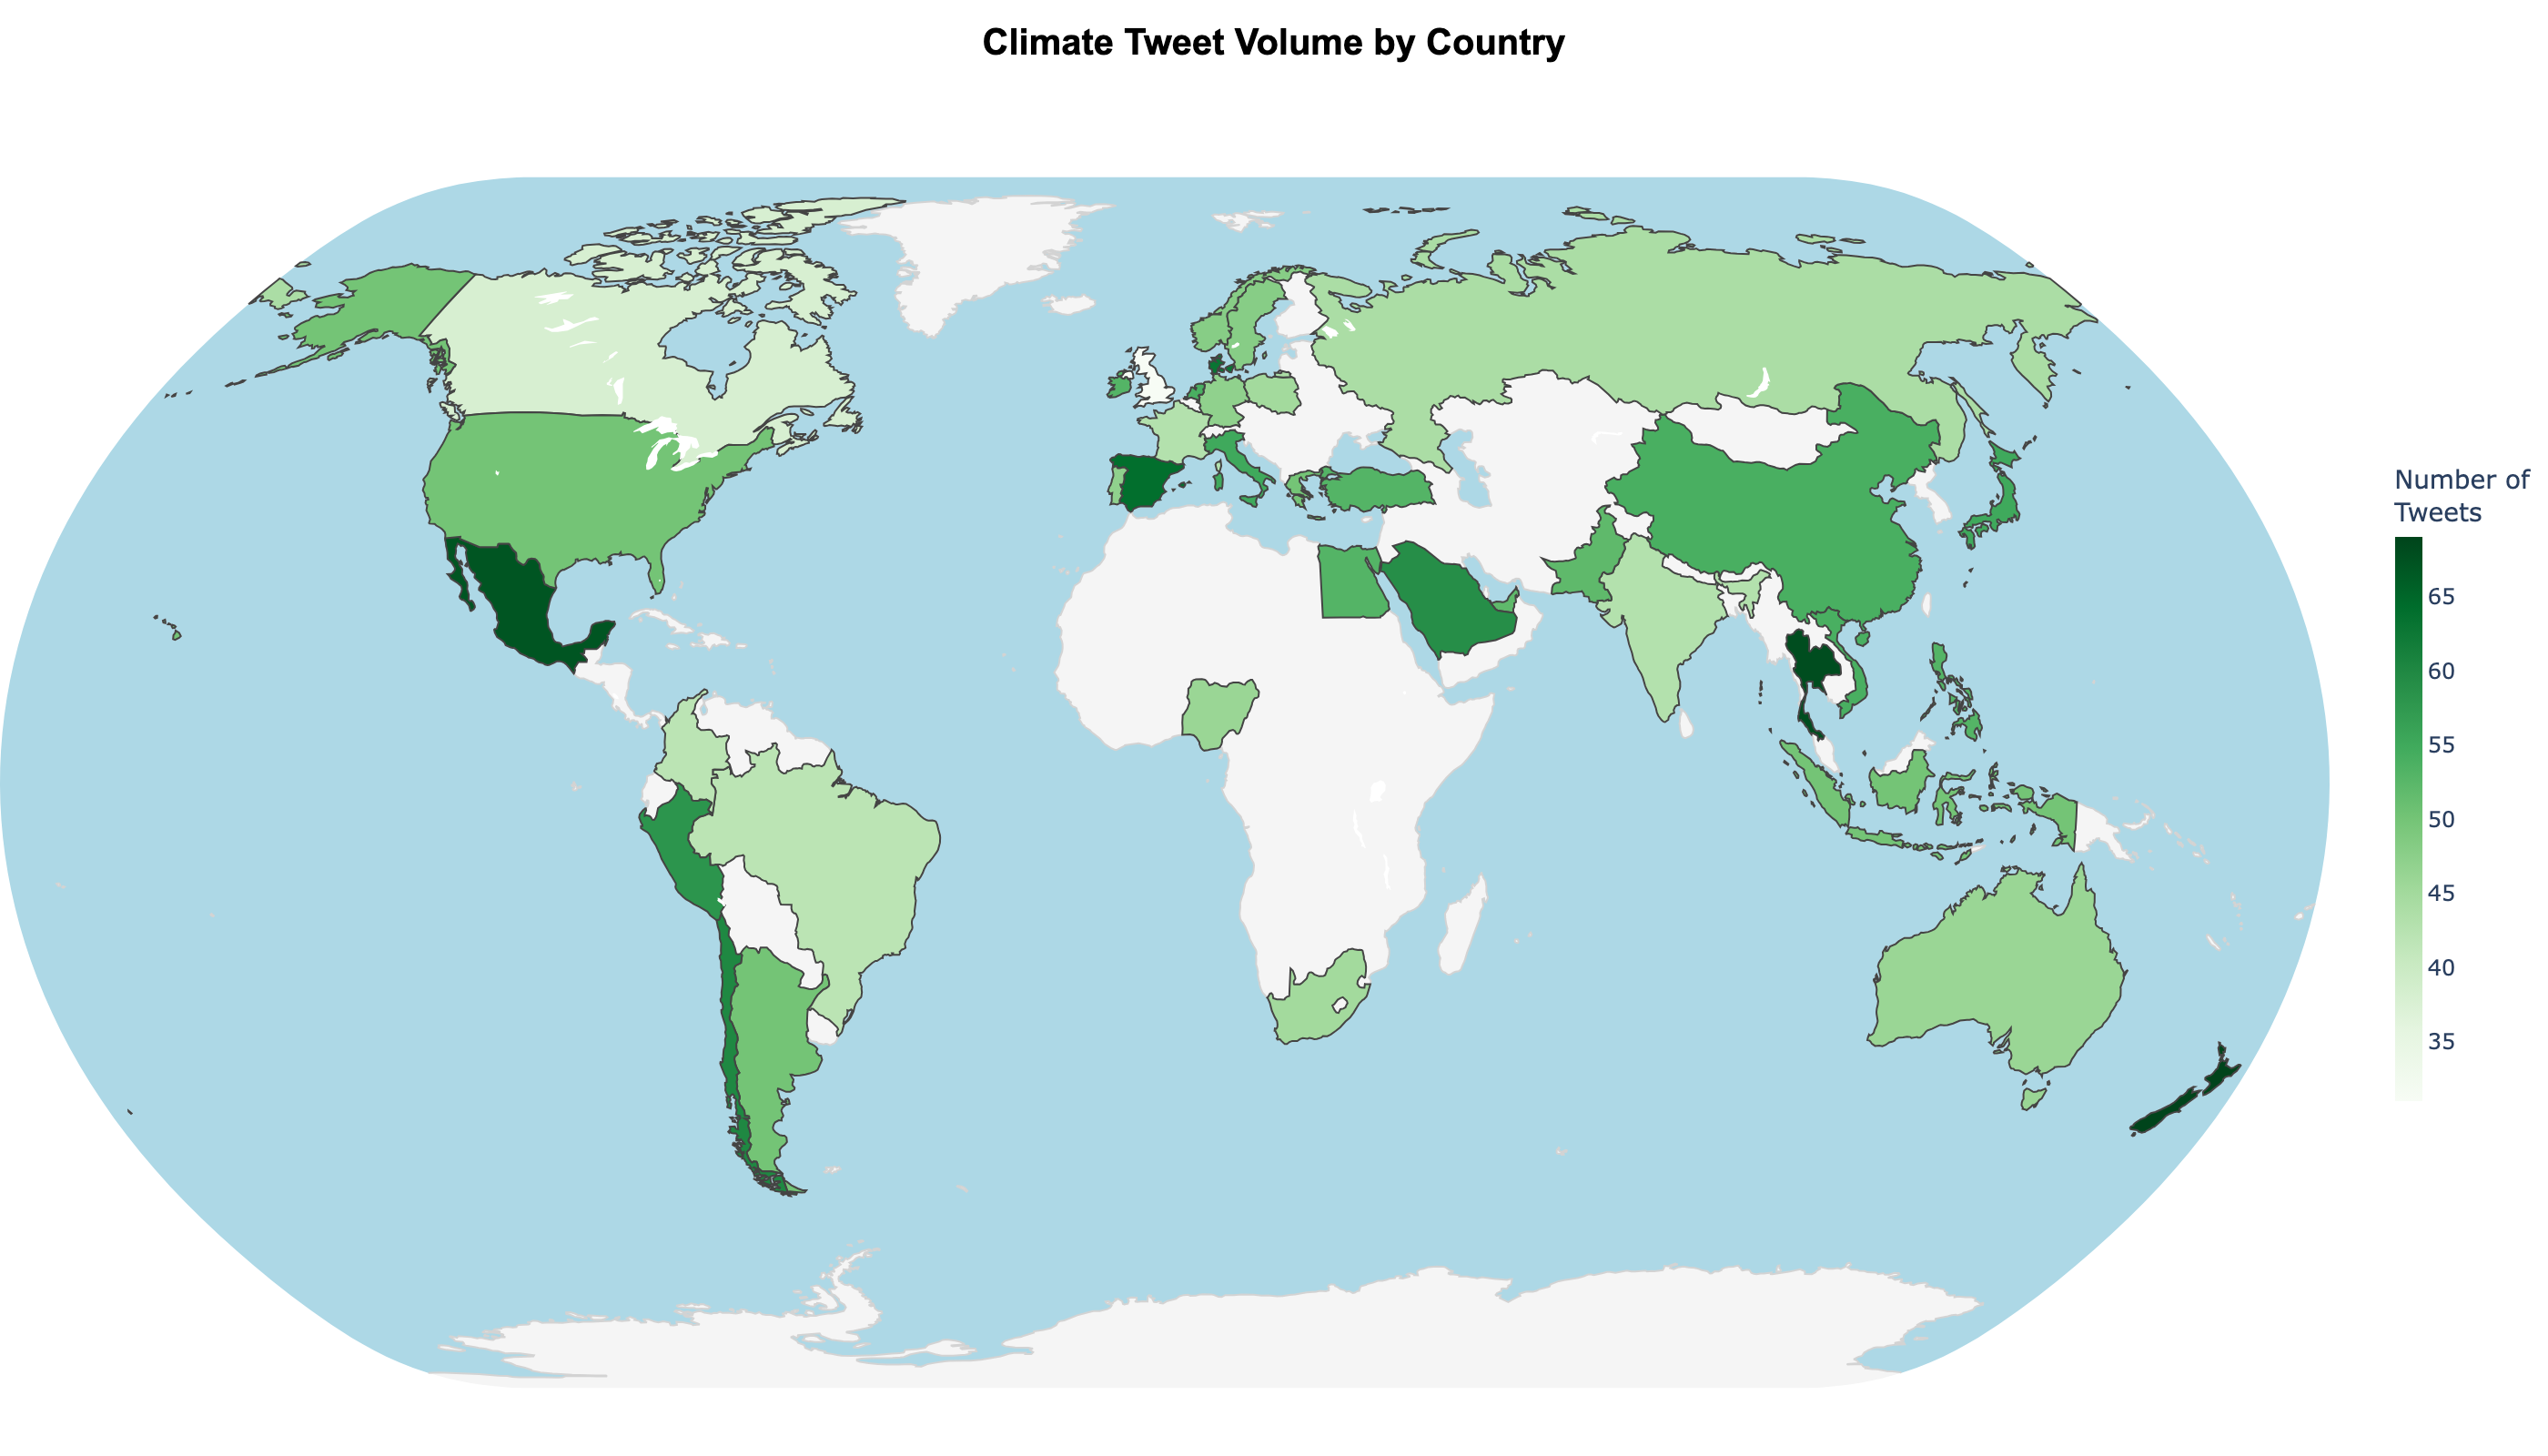

In [8]:
#Part C - Geospatial Visualization
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'

country_name_fixes = {'Russia': 'Russian Federation',}

df['Country'] = df['Country'].replace(country_name_fixes)

#ISO-3 country names
iso3_map = {
    'Argentina'            : 'ARG',
    'Australia'            : 'AUS',
    'Brazil'               : 'BRA',
    'Canada'               : 'CAN',
    'Chile'                : 'CHL',
    'China'                : 'CHN',
    'Colombia'             : 'COL',
    'Denmark'              : 'DNK',
    'Egypt'                : 'EGY',
    'France'               : 'FRA',
    'Germany'              : 'DEU',
    'Greece'               : 'GRC',
    'India'                : 'IND',
    'Indonesia'            : 'IDN',
    'Ireland'              : 'IRL',
    'Italy'                : 'ITA',
    'Japan'                : 'JPN',
    'Mexico'               : 'MEX',
    'Netherlands'          : 'NLD',
    'New Zealand'          : 'NZL',
    'Nigeria'              : 'NGA',
    'Norway'               : 'NOR',
    'Pakistan'             : 'PAK',
    'Peru'                 : 'PER',
    'Philippines'          : 'PHL',
    'Poland'               : 'POL',
    'Portugal'             : 'PRT',
    'Russian Federation'   : 'RUS',
    'Saudi Arabia'         : 'SAU',
    'Singapore'            : 'SGP',
    'South Africa'         : 'ZAF',
    'Spain'                : 'ESP',
    'Sweden'               : 'SWE',
    'Thailand'             : 'THA',
    'Turkey'               : 'TUR',
    'United Arab Emirates' : 'ARE',
    'United Kingdom'       : 'GBR',
    'United States'        : 'USA',
    'Vietnam'              : 'VNM',
}

df['ISO3'] = df['Country'].map(iso3_map)

country_counts = df.groupby(['ISO3', 'Country']).size().reset_index(name='Tweet Count')

fig = px.choropleth(
    country_counts,
    locations='ISO3',
    locationmode='ISO-3',
    color='Tweet Count',
    color_continuous_scale='Greens',
    title='Climate Tweet Volume by Country',
    labels={'Tweet Count': 'Number of Tweets'},
    hover_name='Country',
    hover_data={'Tweet Count': True, 'ISO3': False}
)

#use a sequential colour scale so it is easy to see how many tweets countries have in comparison to others

fig.update_layout(
    title=dict(
        text='Climate Tweet Volume by Country',
        x=0.5,
        font=dict(size=20, family='Arial', color='black',weight='bold')
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='lightgrey',
        showland=True,
        landcolor='whitesmoke',
        showocean=True,
        oceancolor='lightblue',
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(
        title='Number of<br>Tweets',
        thickness=15,
        len=0.5,
        tickformat=', d'
    ),
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.write_image('choropleth_total.png', width=1400, height=800, scale=2)
fig.write_html('choropleth_total.html')

fig.show()

#display inline in the notebook so it shows in the PDF, colour legend was getting cutoff
from IPython.display import Image
Image('choropleth_total.png')

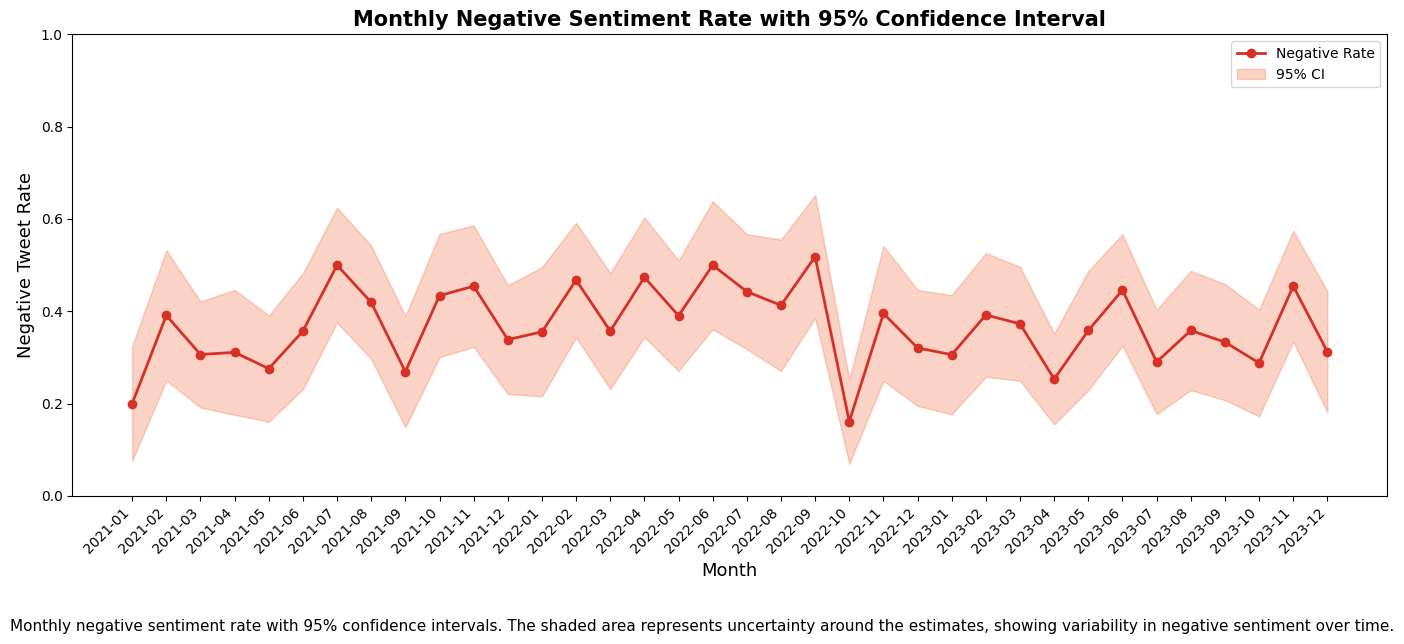

In [9]:
#Part D - Uncertainty & Association

#monthly negative sentiment rate
df['Month'] = df['Date'].dt.to_period('M').astype(str)

monthly = df.groupby('Month').agg(
    total_tweets=('Sentiment','count'),
    negative_tweets=('Sentiment', lambda x: (x=='Negative').sum())
).reset_index()

monthly['neg_rate'] = monthly['negative_tweets'] / monthly['total_tweets']

#95% confidence interval calculation
z = 1.96

monthly['se'] = np.sqrt(
    (monthly['neg_rate'] * (1 - monthly['neg_rate'])) /
    monthly['total_tweets']
)

monthly['lower_ci'] = (monthly['neg_rate'] - (z * monthly['se'])).clip(0, 1)
monthly['upper_ci'] = (monthly['neg_rate'] + (z * monthly['se'])).clip(0, 1)

x = range(len(monthly['Month']))
labels = monthly['Month'].tolist()

#plot
plt.figure(figsize=(14, 6))

plt.plot(x, monthly['neg_rate'],
         color='#d73027', marker='o', linewidth=2, label='Negative Rate')

plt.fill_between(x,
                 monthly['lower_ci'],
                 monthly['upper_ci'],
                 color='#f46d43', alpha=0.3, label='95% CI')

plt.xticks(ticks=x, labels=labels, rotation=45, ha='right')

plt.xlabel("Month", fontsize=13)
plt.ylabel("Negative Tweet Rate", fontsize=13)
plt.title("Monthly Negative Sentiment Rate with 95% Confidence Interval",
          fontsize=15, fontweight='bold')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.figtext(0.5, -0.06,
            "Monthly negative sentiment rate with 95% confidence intervals. The shaded area represents uncertainty around the estimates, showing variability in negative sentiment over time.",
            wrap=True, ha='center', fontsize=11)
plt.show()

The monthly negative sentiment rate was calculated as the proportion of negative tweets relative to the total number of tweets per month. A 95% confidence interval was computed using the normal approximation for binomial proportions. The standard error was estimated as √(p(1−p)/n), where p is the negative sentiment rate and n is the total number of tweets in the month. This allows visualization of uncertainty around the estimated sentiment rate over time.

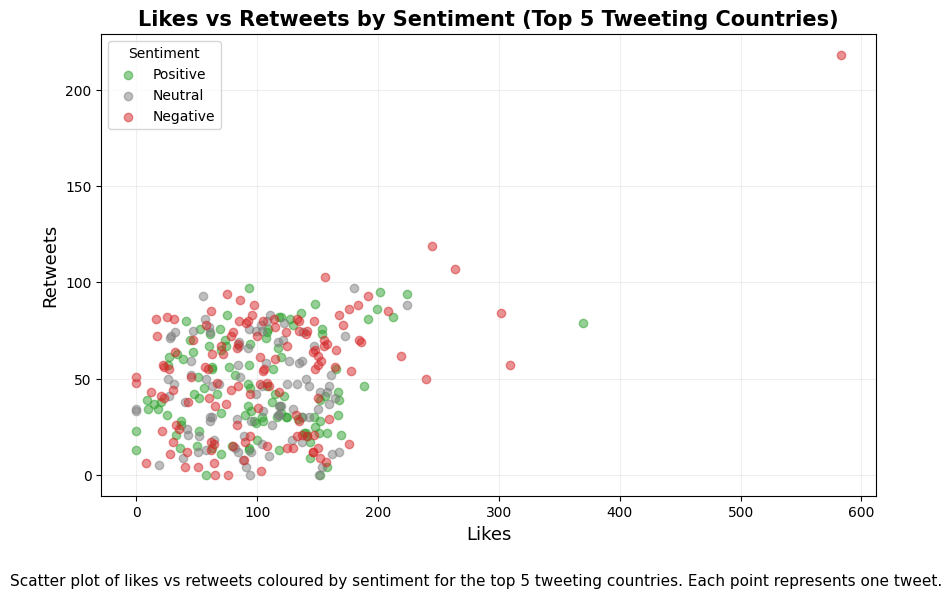

In [10]:
#scatter plot for likes vs. retweets
top5 = df['Country'].value_counts().head(5).index
df_top = df[df['Country'].isin(top5)]

#same colours for the sentiment again since they are intuitive
colors = {
    'Positive': '#2ca02c',
    'Neutral': '#7f7f7f',
    'Negative': '#d62728'
}

plt.figure(figsize=(10,6))

for sentiment, color in colors.items():
    subset = df_top[df_top['Sentiment'] == sentiment]

    plt.scatter(
        subset['Like Count'],
        subset['Retweet Count'],
        c=color,
        alpha=0.5,
        label=sentiment
    )

plt.xlabel("Likes", fontsize=13)
plt.ylabel("Retweets", fontsize=13)
plt.title("Likes vs Retweets by Sentiment (Top 5 Tweeting Countries)", fontsize=15, fontweight='bold')
plt.legend(title="Sentiment")
plt.figtext(0.5, -0.04,
            "Scatter plot of likes vs retweets coloured by sentiment for the top 5 tweeting countries. Each point represents one tweet.",
            wrap=True, ha='center', fontsize=11)
plt.grid(alpha=0.2)

plt.show()

A scatter plot was chosen instead of a bubble plot to clearly show individual tweet distribution without exaggerating counts, while maintaining readability.

To reduce overplotting and improve readability, the scatter plot focuses on tweets from the top five countries with the highest tweet volumes. Each point represents an individual tweet, with the x-axis showing the number of likes and the y-axis showing the number of retweets. Points are colored by sentiment category (positive, neutral, and negative).

The plot suggests a positive relationship between likes and retweets, meaning tweets that receive more likes also tend to receive more retweets. Most tweets cluster in the lower engagement range, typically between 0–200 likes and 0–100 retweets, indicating that the majority of tweets receive relatively modest interaction.

There are also a few outlier tweets with very high engagement, such as a tweet with more than 500 likes and over 200 retweets. These highly engaged tweets demonstrate that some posts gain significantly more visibility and interaction than the typical tweet in the dataset, potentially due to factors such as greater audience reach, general twitter algorithm, or the popularity of the user or content.

Sentiment categories appear to overlap across similar engagement ranges, suggesting that tweet engagement is not strongly determined by sentiment alone. 

## Part E – Design & Insight

### Design Choices
Consistent red, grey, and green colouring was used across all sentiment 
visualizations to allow intuitive comparison between charts. Sequential 
colour scales were chosen for the choropleth to clearly communicate magnitude 
differences in tweet volume across countries. The scatter plot was filtered to 
the top 5 countries to reduce overplotting while remaining representative 
of the dataset.

### Insight
Climate tweet activity is concentrated among a small number of countries, 
suggesting that global discourse on climate change is not evenly distributed 
and may reflect differences in internet access, political climate, or media 
focus. Negative sentiment accounts for a consistent 30–40% of monthly tweets 
throughout the dataset, indicating sustained concern rather than isolated 
spikes of negativity. Confidence intervals widen noticeably in months with 
lower tweet volumes, highlighting that conclusions drawn from those periods 
carry greater uncertainty and should be interpreted cautiously. The positive 
relationship between likes and retweets across all sentiment categories 
suggests that engagement is driven more by topic relevance than emotional 
tone. Together, these patterns suggest that climate discourse online is 
both persistent and emotionally charged, concentrated in certain regions, and 
amplified through shared engagement regardless of whether the message is 
positive or negative.